In [ ]:
# 1. Install and import required libraries
# Scikit-learn provides the Iris dataset, MLP classifier,
# train-test split, accuracy score, and confusion matrix.
# Matplotlib and Seaborn are used for visualization.

%pip install scikit-learn matplotlib seaborn

In [2]:
# 2. Import required libraries
# NumPy is used for numerical operations.
# Pandas is used for handling the dataset.
# Matplotlib and Seaborn are used for visualization.
# Scikit-learn is used for the MLP model and evaluation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# 3. Load the Iris dataset
# The Iris dataset contains measurements of iris flowers.
# It has four input features and three output classes.

iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully.")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:", iris.target_names)

Dataset loaded successfully.
Feature shape: (150, 4)
Target shape: (150,)
Class names: ['setosa' 'versicolor' 'virginica']


In [4]:
# 4. Display the dataset
# Convert the Iris dataset into a Pandas DataFrame
# to understand the features and class labels.

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
# 5. Analyze the dataset
# Check the number of samples, features, and classes
# present in the Iris dataset.

print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(iris.target_names))

print("\nClass distribution:")
print(df["target"].value_counts().sort_index())

Number of samples: 150
Number of features: 4
Number of classes: 3

Class distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


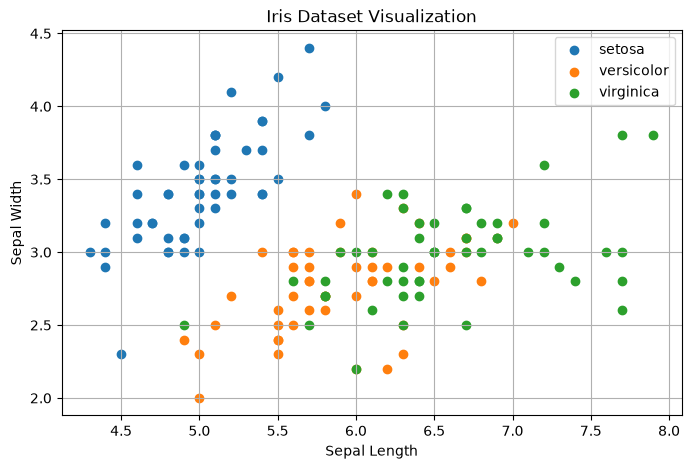

In [6]:
# 6. Visualize the Iris dataset
# A scatter plot is used to visualize the relationship
# between sepal length and sepal width for different classes.

plt.figure(figsize=(8, 5))

for i, name in enumerate(iris.target_names):
    plt.scatter(
        X[y == i, 0],
        X[y == i, 1],
        label=name
    )

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Dataset Visualization")
plt.legend()
plt.grid()

plt.show()

In [7]:
# 7. Split the dataset into training and testing sets
# 80% of the data is used for training.
# 20% of the data is used for testing.
# random_state ensures that the same split is obtained each time.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [8]:
# 8. Feature scaling
# StandardScaler standardizes the features so that
# they have approximately zero mean and unit variance.
# Feature scaling helps the MLP model train effectively.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")
print("First scaled training sample:")
print(X_train[0])

Feature scaling completed.
First scaled training sample:
[-1.72156775 -0.33210111 -1.34572231 -1.32327558]


In [9]:
# 9. Design the Multilayer Perceptron (MLP)
# The MLP contains:
# - Input layer: 4 features
# - Hidden layer 1: 10 neurons
# - Hidden layer 2: 10 neurons
# - Output layer: 3 classes
#
# ReLU is used as the activation function in hidden layers.

mlp_model = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

print("MLP model created successfully.")

MLP model created successfully.


In [10]:
# 10. Train the MLP model
# The model learns the relationship between the four
# input features and the three Iris flower classes.

mlp_model.fit(X_train, y_train)

print("MLP model training completed.")

MLP model training completed.


In [11]:
# 11. Make predictions on the test dataset
# The trained MLP model predicts the class of each
# previously unseen test sample.

y_pred = mlp_model.predict(X_test)

print("Predictions generated successfully.")
print("Predicted classes:", y_pred)

Predictions generated successfully.
Predicted classes: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [12]:
# 12. Evaluate the model using accuracy
# Accuracy represents the percentage of test samples
# that were classified correctly.

accuracy = accuracy_score(y_test, y_pred)

print("MLP Classification Accuracy:", accuracy)
print("MLP Classification Accuracy: {:.2f}%".format(accuracy * 100))

MLP Classification Accuracy: 0.9666666666666667
MLP Classification Accuracy: 96.67%


In [13]:
# 13. Generate the confusion matrix
# The confusion matrix shows the number of correct
# and incorrect predictions for each Iris class.

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


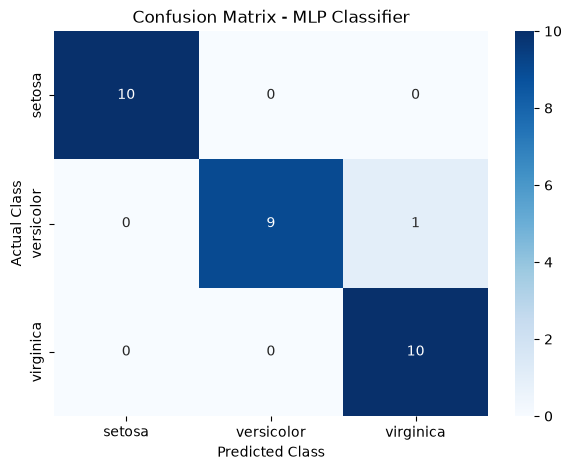

In [14]:
# 14. Visualize the confusion matrix
# The heatmap provides a graphical representation
# of the model's classification performance.

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - MLP Classifier")

plt.show()

In [16]:
# 15. Display final model performance
# Print the final accuracy and summarize the evaluation.

print("=" * 50)
print("MLP CLASSIFICATION RESULTS")
print("=" * 50)

print("Dataset: Iris")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Hidden layers: 2")
print("Neurons per hidden layer: 10")
print("Activation function: ReLU")
print("Optimizer: Adam")
print("Accuracy: {:.2f}%".format(accuracy * 100))

print("\nConfusion Matrix:")
print(cm)

print("=" * 50)

MLP CLASSIFICATION RESULTS
Dataset: Iris
Training samples: 120
Testing samples: 30
Hidden layers: 2
Neurons per hidden layer: 10
Activation function: ReLU
Optimizer: Adam
Accuracy: 96.67%

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


# Result

The Multilayer Perceptron (MLP) classifier was successfully designed and implemented for classification of the Iris dataset.

The dataset was divided into training and testing sets using an 80:20 ratio. The input features were standardized using StandardScaler before training the MLP model.

The MLP model consisted of two hidden layers with 10 neurons each and used ReLU activation with the Adam optimizer.

The trained model was evaluated using classification accuracy and a confusion matrix. The confusion matrix was visualized using a heatmap to understand the correct and incorrect classifications for each Iris class.

## Conclusion

The MLP model successfully learned the patterns in the Iris dataset and classified the three Iris flower species. The accuracy and confusion matrix demonstrate the performance of the trained neural network.